A: [[1 2]
 [3 4]]
Shape: (2, 2)
Transpose: [[1 3]
 [2 4]]
A @ B: [[19 22]
 [43 50]]
B @ A: [[23 34]
 [31 46]]
A @ x: [ 5 11]
Identity: [[1. 0.]
 [0. 1.]]
I @ x: [1. 2.]
A_inv: [[-2.   1. ]
 [ 1.5 -0.5]]
A @ A_inv: [[1. 0.]
 [0. 1.]]
det(A): -2.0
det(singular): 0.0


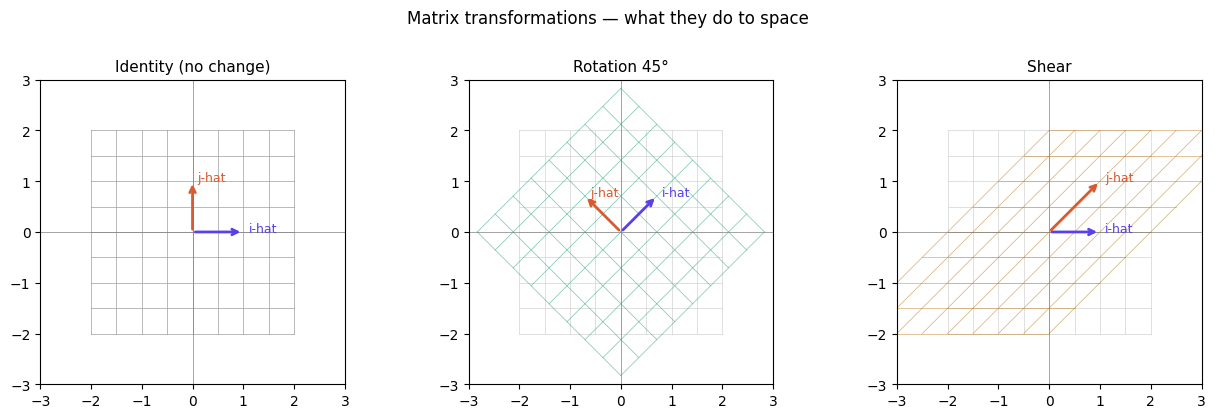

Save as day03_matrices.ipynb and push to GitHub.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Matrix creation ───────────────────────────────────
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A:", A)
print("Shape:", A.shape)          # (2, 2)
print("Transpose:", A.T)

# ── 2. Matrix multiplication ─────────────────────────────
C = A @ B                         # preferred over np.matmul or np.dot
print("A @ B:", C)
print("B @ A:", B @ A)          # different! non-commutative

# ── 3. Matrix × vector (core neural net operation) ───────
x = np.array([1, 2])
print("A @ x:", A @ x)          # [5, 11]  → transformed vector

# ── 4. Identity matrix ───────────────────────────────────
I = np.eye(2)
print("Identity:", I)
print("I @ x:", I @ x)           # [1, 2]  → unchanged

# ── 5. Inverse ───────────────────────────────────────────
A_inv = np.linalg.inv(A)
print("A_inv:", A_inv.round(4))
print("A @ A_inv:", (A @ A_inv).round(4))  # should be identity

# ── 6. Determinant ───────────────────────────────────────
print("det(A):", np.linalg.det(A).round(4))   # -2.0
singular = np.array([[1,2],[2,4]])
print("det(singular):", np.linalg.det(singular).round(6))  # 0.0

# ── 7. Visualise transformations — the money shot ────────
def plot_transform(ax, M, title, color):
    # draw original grid
    for i in np.linspace(-2, 2, 9):
        pts = np.array([[i,i],[-2,2]])
        ax.plot(pts[0], pts[1], 'lightgray', lw=0.5)
        ax.plot(pts[1], pts[0], 'lightgray', lw=0.5)
    # transform and draw new grid
    for i in np.linspace(-2, 2, 9):
        col_pts = np.array([[i]*50, np.linspace(-2,2,50)])
        row_pts = np.array([np.linspace(-2,2,50), [i]*50])
        tc = M @ col_pts
        tr = M @ row_pts
        ax.plot(tc[0], tc[1], color=color, lw=0.5, alpha=0.6)
        ax.plot(tr[0], tr[1], color=color, lw=0.5, alpha=0.6)
    # basis vectors
    origin = np.zeros(2)
    e1 = M @ np.array([1,0])
    e2 = M @ np.array([0,1])
    ax.annotate('',xy=e1,xytext=origin,arrowprops=dict(arrowstyle='->',color='#5B3FE8',lw=2))
    ax.annotate('',xy=e2,xytext=origin,arrowprops=dict(arrowstyle='->',color='#D85A30',lw=2))
    ax.text(e1[0]+0.1,e1[1],'i-hat',color='#5B3FE8',fontsize=9)
    ax.text(e2[0]+0.1,e2[1],'j-hat',color='#D85A30',fontsize=9)
    ax.set_xlim(-3,3); ax.set_ylim(-3,3)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=11)
    ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# identity — no change
plot_transform(axes[0], np.eye(2), 'Identity (no change)', '#888')

# rotation 45 degrees
theta = np.pi/4
R = np.array([[np.cos(theta),-np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
plot_transform(axes[1], R, 'Rotation 45°', '#1D9E75')

# shear
S = np.array([[1, 1],
              [0, 1]])
plot_transform(axes[2], S, 'Shear', '#BA7517')

plt.suptitle('Matrix transformations — what they do to space', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Save as day03_matrices.ipynb and push to GitHub.")